In [625]:
#imports
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from matplotlib.collections import PatchCollection
from mpl_toolkits.mplot3d import Axes3D


In [626]:
# Constants
Gravitational_Constant=6.6743*(10**-1)
dt=1.0
total_time=1000
time=0.0

In [627]:
def normalize_unit_vector(v):
    norm = np.linalg.norm(v)
    if norm == 0: 
        return v
    return v / norm

In [628]:
#very rough please simplify when you can. Prob cant if we have initial constants
class Body:
    def __init__(self, mass, pos, velo, accel, force):
        self.mass=mass
        self.pos=np.array(pos,dtype=float)
        self.velo=np.array(velo,dtype=float)
        self.accel=np.array(accel,dtype=float)
        self.force=np.array(force,dtype=float)
        
        self.history_pos = [self.pos.copy()]
        self.history_velo = [self.velo.copy()]
        self.history_accel = [self.accel.copy()]
        self.history_force = [self.force.copy()]

    def update_history(self):
        self.history_pos.append(self.pos.copy())
        self.history_velo.append(self.velo.copy())
        self.history_accel.append(self.accel.copy())
        self.history_force.append(self.force.copy())
    
    def get_gravitational_force_2bodies(self, other):
        r_vec = other.pos-self.pos
        dist = np.linalg.norm(r_vec)
        if dist > 10**6:
            zeros=[0,0]
            returnzero=np.array(zeros)
            return (returnzero)
        mag = normalize_unit_vector(r_vec) * ((Gravitational_Constant*self.mass*other.mass)/(dist**2))
        print(mag)
        return (mag)

    

In [629]:
def combining_2_vectors(vector1, vector2): #combines the force of b2 on b1 and b3 on b1 for a total g force acted on b1
    array_one = np.array(vector1)
    array_two = np.array(vector2)
    summed_array = array_one + array_two
    return (summed_array)

In [630]:
bodies = []
bodies.append(Body( 5*10**8, [10*10**3, -5*10**3], [10**1, 10**1], [0, 0], [0, 0])) #mass and initial( pos velo accel force )
bodies.append(Body( 3*10**8, [2*10**3, 0], [-2*10**1, 0], [0, 0], [0, 0]))
bodies.append(Body( 6*10**8, [-8*10**3, 10*10**3], [9*10**1, -5*10**1], [0, 0], [0, 0]))

center_of_mass = (bodies[0].mass*bodies[0].pos + bodies[1].mass*bodies[1].pos + bodies[2].mass*bodies[2].pos)/(bodies[0].mass*bodies[1].mass*bodies[2].mass)

In [631]:
def CalcTV(bodies):
    T=.5*(bodies[0].mass*(np.linalg.norm(bodies[0].velo)**2) +bodies[1].mass*(np.linalg.norm(bodies[1].velo)**2) +bodies[2].mass*(np.linalg.norm(bodies[2].velo)**2))
    distance_from_center_1=bodies[0].pos-center_of_mass
    distnace_from_center_2=bodies[1].pos-center_of_mass
    distnace_from_center_3=bodies[2].pos-center_of_mass
    
    V=np.linalg.norm((distance_from_center_1*np.linalg.norm(bodies[0].force)) + (distnace_from_center_2*np.linalg.norm(bodies[1].force)) + (distnace_from_center_3*np.linalg.norm(bodies[2].force)))
    print(T)
    print(V)
    return (T,V)

In [632]:
vector1=np.zeros(2) 
vector2=np.zeros(2)
comb_vector1=np.zeros(2)
comb_vector2=np.zeros(2)
comb_vector3=np.zeros(2)
T_history=[]
V_history=[]
while (time!=total_time):
    vector1=bodies[0].get_gravitational_force_2bodies(bodies[1])
    vector2=bodies[0].get_gravitational_force_2bodies(bodies[2])
    comb_vector1=combining_2_vectors(vector1,vector2)

    vector1=bodies[1].get_gravitational_force_2bodies(bodies[0])
    vector2=bodies[1].get_gravitational_force_2bodies(bodies[2])
    comb_vector2=combining_2_vectors(vector1,vector2)

    vector1=bodies[2].get_gravitational_force_2bodies(bodies[0])
    vector2=bodies[2].get_gravitational_force_2bodies(bodies[1])
    comb_vector3=combining_2_vectors(vector1,vector2)
    
    bodies[0].force=comb_vector1
    bodies[1].force=comb_vector2
    bodies[2].force=comb_vector3
    for body in bodies:
        body.accel = body.force/body.mass
        body.velo += body.accel*dt
        body.pos += body.velo*dt
        body.update_history()
        if body == bodies[2]:  #only needs the 3rd body as that is the last updated body meaning tat the system is fully updated
            # print(time,":")
            newt,newv=CalcTV(bodies)
            T_history.append(newt)
            V_history.append(newv)
            # print("\n")
    time+=dt
    # print(T_history)
    # print(V_history)


[-9.53898047e+08  5.96186280e+08]
[-2.80182475e+08  2.33485396e+08]
[ 9.53898047e+08 -5.96186280e+08]
[-4.24749851e+08  4.24749851e+08]
[ 2.80182475e+08 -2.33485396e+08]
[ 4.24749851e+08 -4.24749851e+08]
3375230745536.046
8635135635903.611
[-9.52299506e+08  5.91824999e+08]
[-2.82642933e+08  2.35645358e+08]
[ 9.52299506e+08 -5.91824999e+08]
[-4.30338769e+08  4.32900871e+08]
[ 2.82642933e+08 -2.35645358e+08]
[ 4.30338769e+08 -4.32900871e+08]
3468818180349.04
8622557121960.677
[-9.51611855e+08  5.88108671e+08]
[-2.85246243e+08  2.37931933e+08]
[ 9.51611855e+08 -5.88108671e+08]
[-4.36048202e+08  4.41247529e+08]
[ 2.85246243e+08 -2.37931933e+08]
[ 4.36048202e+08 -4.41247529e+08]
3570803206675.693
8623168216773.998
[-9.51824005e+08  5.85018975e+08]
[-2.87998153e+08  2.40350399e+08]
[ 9.51824005e+08 -5.85018975e+08]
[-4.41886915e+08  4.49799971e+08]
[ 2.87998153e+08 -2.40350399e+08]
[ 4.41886915e+08 -4.49799971e+08]
3681256355673.781
8636564292223.574
[-9.52929832e+08  5.82541426e+08]
[-2.909

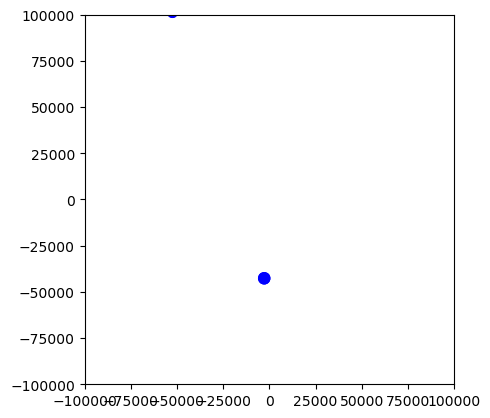

In [633]:
#individual frames 

fig, axies = plt.subplots()

patches = []
for body in bodies:
    circle = axies.add_patch(plt.Circle(body.history_pos[200][0:2], radius = body.mass/200000, color = 'b'))
    axies.add_patch(circle);


axies.set_xlim(-10**5, 10**5)
axies.set_ylim(-10**5, 10**5)
axies.set_aspect('equal', adjustable='box')


plt.show()

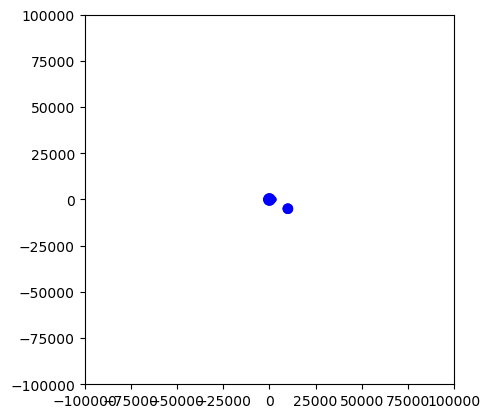

In [635]:
#lets draw a visualization!!!

fig, axies = plt.subplots()

body_1 = axies.add_patch(plt.Circle(bodies[0].history_pos[0][0:2], radius = bodies[0].mass/200000, color = 'b'))
body_2 = axies.add_patch(plt.Circle(bodies[1].history_pos[0][0:2], radius = bodies[1].mass/200000, color = 'b'))
body_3 = axies.add_patch(plt.Circle(bodies[2].history_pos[0][0:2], radius = bodies[2].mass/200000, color = 'b'))
axies.add_patch(body_1)
axies.add_patch(body_2)
axies.add_patch(body_3)

    
def update(frame):
    body_1.center = bodies[0].history_pos[frame][0:2]
    body_2.center = bodies[1].history_pos[frame][0:2]
    body_3.center = [frame*1000, frame*1000]
    return (body_1, body_2, body_3)


axies.set_xlim(-10**5, 10**5)
axies.set_ylim(-10**5, 10**5)
axies.set_aspect('equal', adjustable='box')

animate = animation.FuncAnimation(fig=fig, func=update, frames=1000, interval=20, blit=True, repeat=True)

plt.show()